<a href="https://colab.research.google.com/github/Paulo123213/MineriaDatos/blob/PauloGuerra/prueba2mineria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Comprensión del Negocio

# 2. Comprensión de los Datos

In [32]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import HistGradientBoostingRegressor

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("limguowei/tetrio-tetra-league-historical-data")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'tetrio-tetra-league-historical-data' dataset.
Path to dataset files: /kaggle/input/tetrio-tetra-league-historical-data


In [9]:

df = pd.read_csv(os.path.join(path, 'tl-calculated-delta-table.csv'))

In [10]:
# List the contents of the downloaded directory to find the CSV file
print("Contents of the downloaded directory:")
for filename in os.listdir(path):
    print(filename)

Contents of the downloaded directory:
tl-calculated-delta-table.csv
tl-delta-table-v2.0.csv


### 3.2.1 Diccionario de Datos

# 3. Preparación de los Datos

## 3.1 Depuración de los Datos

In [11]:
df_clean = pd.read_csv(os.path.join(path, 'tl-calculated-delta-table.csv'))

In [12]:
df_clean = df_clean.drop(columns=['vs', 'raw_eff', 'adjusted_eff', 'verified'])

In [13]:
df_clean['tlrank'] = df_clean['tlrank'].astype(str).str.strip().str.lower()

In [14]:
df_clean.head(10)

,id,username,tlrank,apm,pps,raw_app,adjusted_app,tr,glicko,rd,gamesplayed,gameswon,deltadate
0,5e484c3eadfab42c76f0af36,vince,x,139.63,3.44,0.676502,0.452287,24546.0,2553.0,85,31,26,2020-04-08 17:42:00
1,5e3f6ebe3dacc16dbc4dd6aa,doremy,x,116.71,2.79,0.697192,0.465930,24266.0,2419.0,71,100,86,2020-04-08 17:42:00
2,5e40825a4be6907ad7eab03d,sm999,u,128.92,3.32,0.647189,0.432719,24239.0,2409.0,72,72,64,2020-04-08 17:42:00
3,5e3d58e92445dd5207770ca5,wumbo,u,93.24,2.37,0.655696,0.438045,24213.0,2401.0,75,74,67,2020-04-08 17:42:00
4,5e4f0ad196a8426ec442746e,qmk,u,121.82,2.92,0.695320,0.464754,24137.0,2376.0,76,44,39,2020-04-08 17:42:00
5,5e40a2b74be6907ad7eab292,cheep,u,109.59,2.88,0.634201,0.423902,24012.0,2345.0,95,20,14,2020-04-08 17:42:00
6,5e697bbf77aba60f95fb38da,firestorm,u,119.78,2.94,0.679025,0.453900,23948.0,2320.0,70,64,49,2020-04-08 17:42:00
7,5e381f4c456244768a097502,zack101155,u,104.13,2.51,0.691434,0.462049,23638.0,2251.0,79,38,35,2020-04-08 17:42:00
8,5e436daf368a5d2489fbf848,star,u,107.18,2.74,0.651946,0.435760,23570.0,2243.0,99,24,24,2020-04-08 17:42:00
9,5e4db4eff5d51a6eb7ec0bb6,zerot,u,115.67,3.05,0.632077,0.422605,23563.0,2238.0,87,25,22,2020-04-08 17:42:00


In [15]:
df_clean.isna().sum()

,0
id,0
username,0
tlrank,0
apm,0
pps,0
raw_app,0
adjusted_app,0
tr,0
glicko,0
rd,0


In [16]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8177602 entries, 0 to 8177601
Data columns (total 13 columns):
 #   Column        Dtype  
---  ------        -----  
 0   id            object 
 1   username      object 
 2   tlrank        object 
 3   apm           float64
 4   pps           float64
 5   raw_app       float64
 6   adjusted_app  float64
 7   tr            float64
 8   glicko        float64
 9   rd            int64  
 10  gamesplayed   int64  
 11  gameswon      int64  
 12  deltadate     object 
dtypes: float64(6), int64(3), object(4)
memory usage: 811.1+ MB
None


In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8177602 entries, 0 to 8177601
Data columns (total 17 columns):
 #   Column        Dtype  
---  ------        -----  
 0   id            object 
 1   username      object 
 2   tlrank        object 
 3   apm           float64
 4   pps           float64
 5   vs            float64
 6   raw_eff       float64
 7   adjusted_eff  float64
 8   raw_app       float64
 9   adjusted_app  float64
 10  tr            float64
 11  glicko        float64
 12  rd            int64  
 13  gamesplayed   int64  
 14  gameswon      int64  
 15  verified      float64
 16  deltadate     object 
dtypes: float64(10), int64(3), object(4)
memory usage: 1.0+ GB
None


## 3.2 Encoding y Mapeo de Rangos

In [20]:
rank_mapping = {
    'x': 17, 'u': 16, 'ss': 15, 's+': 14, 's': 13, 's-': 12,
    'a+': 11, 'a': 10, 'a-': 9, 'b+': 8, 'b': 7, 'b-': 6,
    'c+': 5, 'c': 4, 'c-': 3, 'd+': 2, 'd': 1, 'z': 0
}
df_clean['rank_num'] = df_clean['tlrank'].map(rank_mapping)

In [21]:
cols_analisis = ['rank_num', 'apm', 'pps', 'raw_app', 'adjusted_app']
for col in cols_analisis:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [22]:
df_final = df_clean[cols_analisis].dropna()

In [23]:
print(f"Registros listos para el análisis: {len(df_final)}")
print(df_final.head())

Registros listos para el análisis: 8177602
   rank_num     apm   pps   raw_app  adjusted_app
0        17  139.63  3.44  0.676502      0.452287
1        17  116.71  2.79  0.697192      0.465930
2        16  128.92  3.32  0.647189      0.432719
3        16   93.24  2.37  0.655696      0.438045
4        16  121.82  2.92  0.695320      0.464754


# 4. Análisis Exploratorio

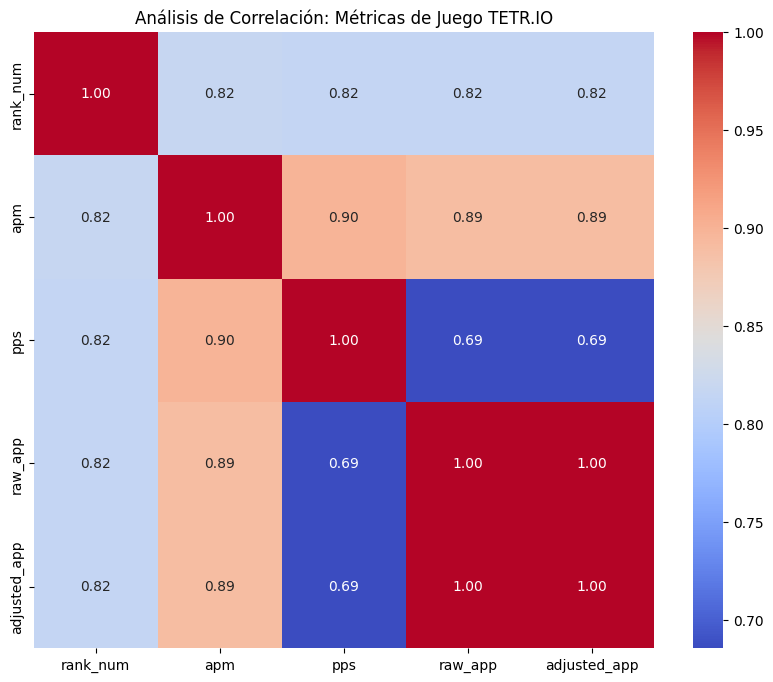

In [24]:
import seaborn as sns

plt.figure(figsize=(10, 8))
# Usamos df_final porque ya está limpio y con los tipos de datos correctos
matriz_corr = df_final.corr()
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Análisis de Correlación: Métricas de Juego TETR.IO')
plt.show()

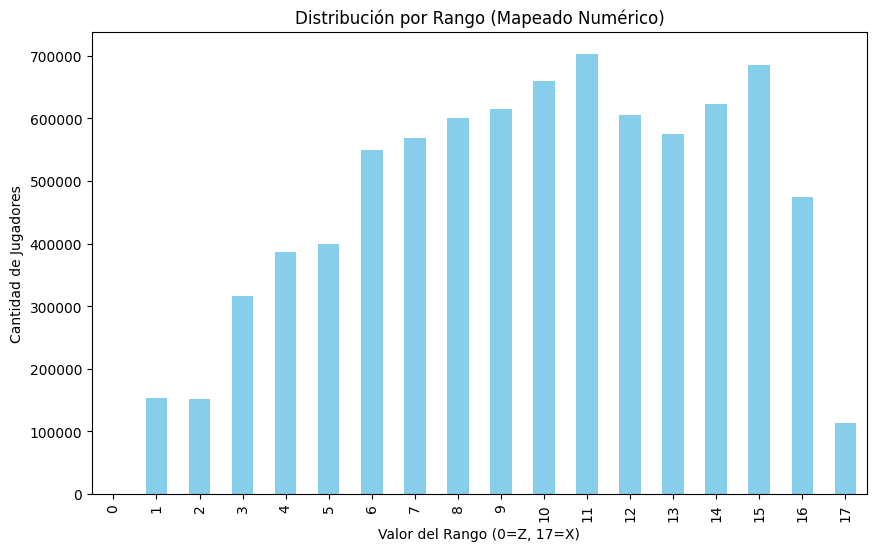

In [25]:
# 7. GRÁFICO DE BARRAS (Distribución por Rango)
plt.figure(figsize=(10, 6))
df_final['rank_num'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribución por Rango (Mapeado Numérico)')
plt.xlabel('Valor del Rango (0=Z, 17=X)')
plt.ylabel('Cantidad de Jugadores')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


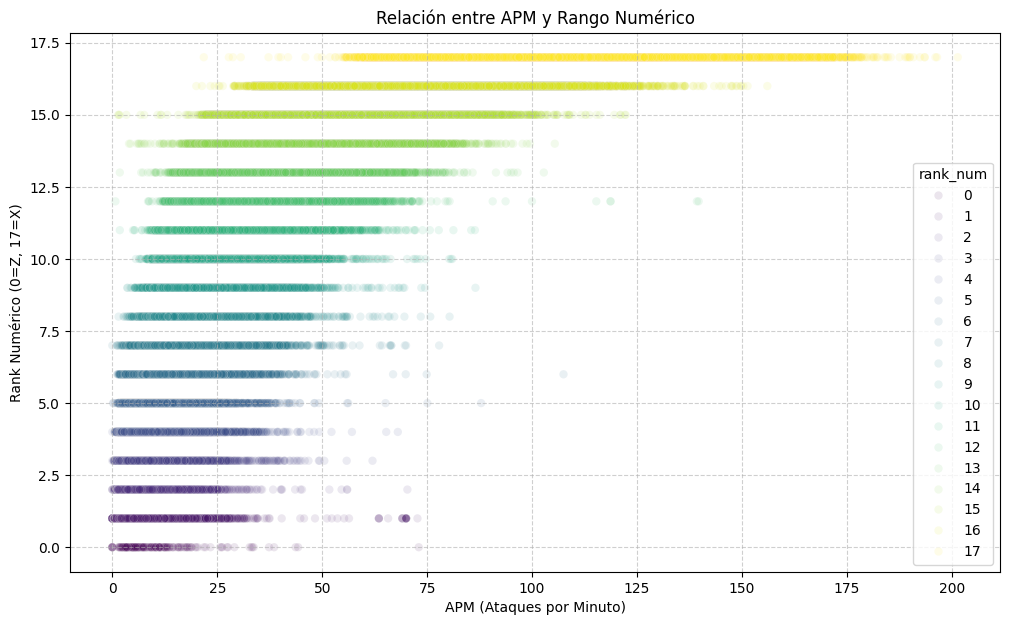

In [26]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='apm', y='rank_num', data=df_final, alpha=0.1, hue='rank_num', palette='viridis', legend='full')
plt.title('Relación entre APM y Rango Numérico')
plt.xlabel('APM (Ataques por Minuto)')
plt.ylabel('Rank Numérico (0=Z, 17=X)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_6673/1088401951.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tlrank', y='apm', data=df_clean, order=orden_rangos, palette="Spectral")


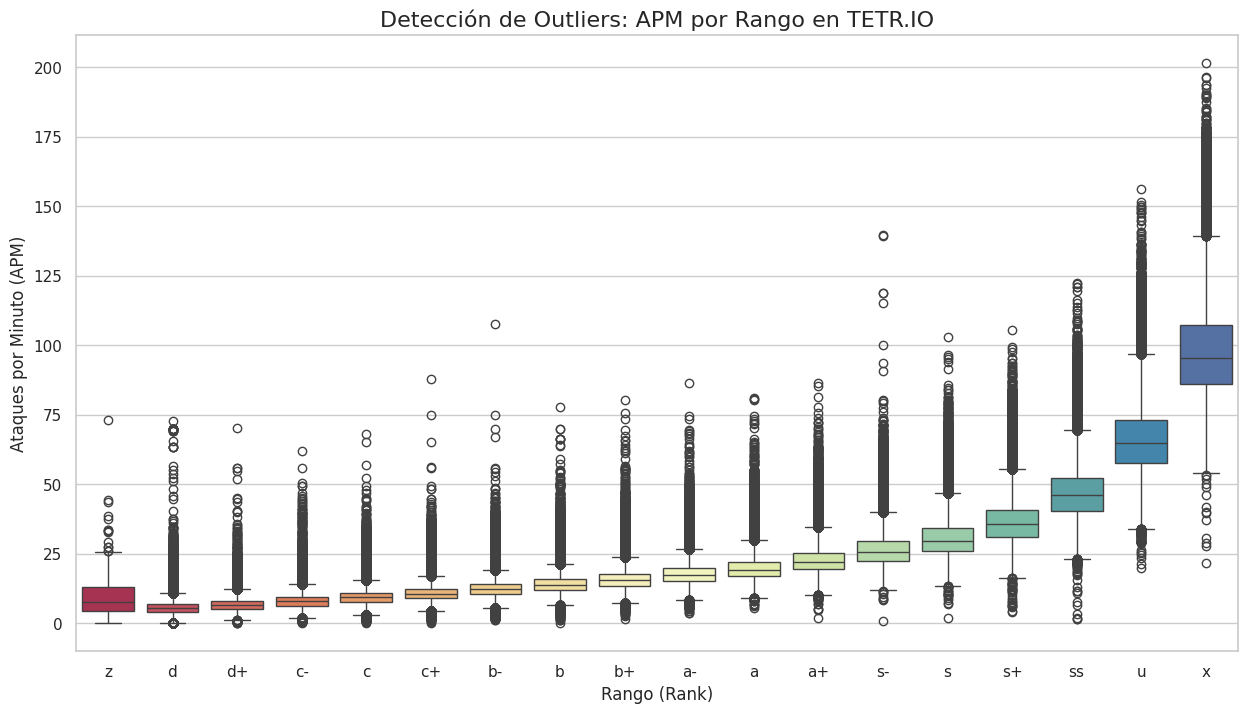

In [27]:
plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

# Usamos tlrank en el eje X para ver las categorías de rango
# Ordenamos los rangos de menor a mayor para que el gráfico tenga sentido
orden_rangos = ['z', 'd', 'd+', 'c-', 'c', 'c+', 'b-', 'b', 'b+', 'a-', 'a', 'a+', 's-', 's', 's+', 'ss', 'u', 'x']

sns.boxplot(x='tlrank', y='apm', data=df_clean, order=orden_rangos, palette="Spectral")

# 3. Personalización
plt.title('Detección de Outliers: APM por Rango en TETR.IO', fontsize=16)
plt.xlabel('Rango (Rank)', fontsize=12)
plt.ylabel('Ataques por Minuto (APM)', fontsize=12)

plt.show()

# 5. Entrenamiento y Evaluación

/tmp/ipykernel_6673/181479770.py:29: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


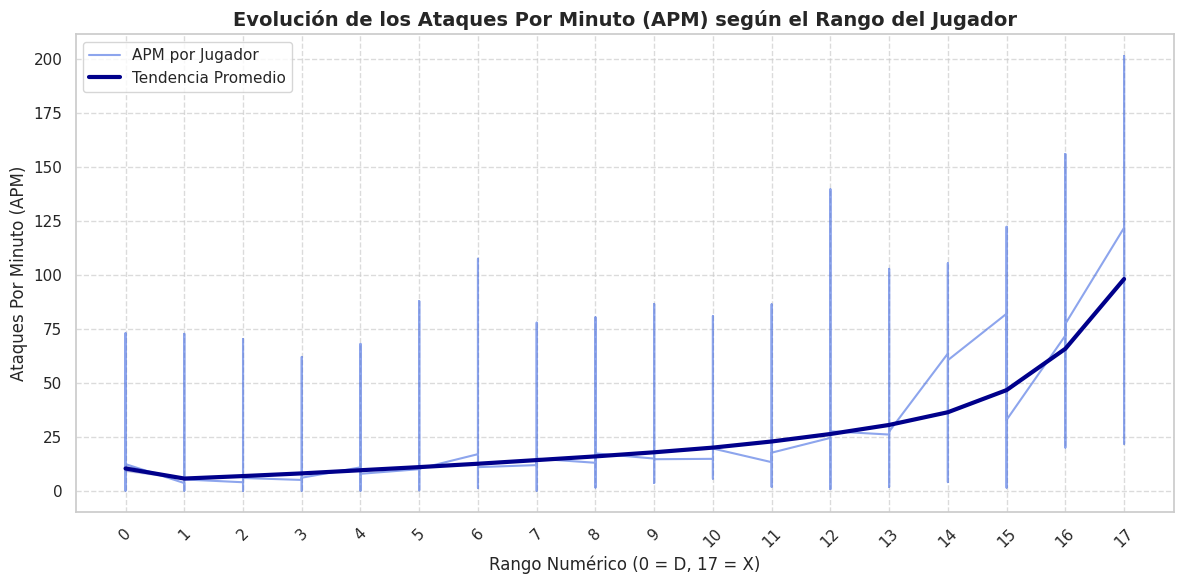

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ordenamos el DataFrame por el rango numérico (de menor a mayor nivel)
df_grafico = df_final.sort_values('rank_num')

# 2. Definimos los ejes (Rango en X, APM en Y)
xpoints = df_grafico['rank_num']
ypoints = df_grafico['apm']

# 3. Creamos el gráfico con el mismo estilo
plt.figure(figsize=(12, 6))

# Usamos un gráfico de dispersión con línea de tendencia o los puntos ordenados
plt.plot(xpoints, ypoints, color='royalblue', linewidth=1.5, alpha=0.6, label='APM por Jugador')

# Extra: Añadimos una línea de tendencia promedio por rango para que se vea aún más claro
sns.lineplot(data=df_grafico, x='rank_num', y='apm', color='darkblue', linewidth=3, label='Tendencia Promedio')

# 4. Formato y etiquetas personalizadas para TETR.IO
plt.title('Evolución de los Ataques Por Minuto (APM) según el Rango del Jugador', fontsize=14, fontweight='bold')
plt.xlabel('Rango Numérico (0 = D, 17 = X)', fontsize=12)
plt.ylabel('Ataques Por Minuto (APM)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(0, 18), rotation=45) # Forzamos a que muestre todos los rangos del 0 al 17 rotados
plt.legend()

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


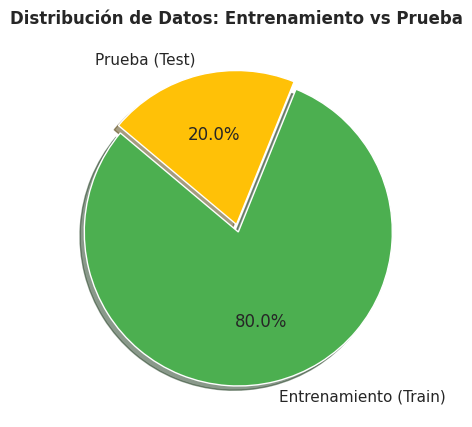

In [30]:
# ==========================================
# 1. TRANSFORMACIÓN PARA MEJORAR RANGOS BAJOS
# ==========================================
# Define features (X_nuevo) and target (y_nuevo) from df_final
X_nuevo = df_final.drop('rank_num', axis=1)
y_nuevo = df_final['rank_num']

# Reducimos la precisión de los datos a float32 (ahorra ~50% de RAM en la matriz)
X_nuevo = X_nuevo.astype('float32')
y_nuevo = y_nuevo.astype('float32')

# Aplicamos escala logarítmica a las características predictoras (X)
# Esto ayuda a que el modelo distinga mucho mejor las sutiles diferencias en APM/PPS bajos
X_balanceado = np.log1p(X_nuevo)
y_balanceado = y_nuevo.copy()

# División de datos estándar
X_train, X_test, y_train, y_test = train_test_split(X_balanceado, y_balanceado, test_size=0.2, random_state=42)

# Gráfico de pastel solicitado
etiquetas = ['Entrenamiento (Train)', 'Prueba (Test)']
cantidades = [X_train.shape[0], X_test.shape[0]]
colores = ['#4CAF50', '#FFC107']

plt.figure(figsize=(5, 5))
plt.pie(cantidades, labels=etiquetas, colors=colores, autopct='%1.1f%%', startangle=140, shadow=True, explode=(0.05, 0))
plt.title('Distribución de Datos: Entrenamiento vs Prueba', fontsize=12, fontweight='bold')
plt.show()

In [33]:
from sklearn.ensemble import HistGradientBoostingRegressor

# ==========================================
# 2. MODELO ENFOCADO EN ERROR ABSOLUTO (MAE)
# ==========================================
print("Entrenando HistGradientBoosting optimizado para rangos bajos...")
# Cambiamos 'loss' a 'absolute_error' para que no ignore los rangos pequeños
modelo_ajustado = HistGradientBoostingRegressor(
    loss='absolute_error',
    max_iter=150,
    learning_rate=0.08,
    random_state=42
)
modelo_ajustado.fit(X_train, y_train)

# Predicción y ajuste de límites mínimos
y_pred_raw = modelo_ajustado.predict(X_test)
rango_minimo_real = y_train.min()
y_pred_final = np.clip(y_pred_raw, a_min=rango_minimo_real, a_max=None)

Entrenando HistGradientBoosting optimizado para rangos bajos...



=== RENDIMIENTO TRAS AJUSTE DE RANGOS BAJOS ===
R2 (Explicación del modelo): 0.8926
MAE (Error promedio en rangos): 0.9932
RMSE: 1.3373


/tmp/ipykernel_6673/1229687619.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_resultados, x='Rango Real', y='Rango Predicho', ax=axes[0], palette='Greens', fliersize=1)


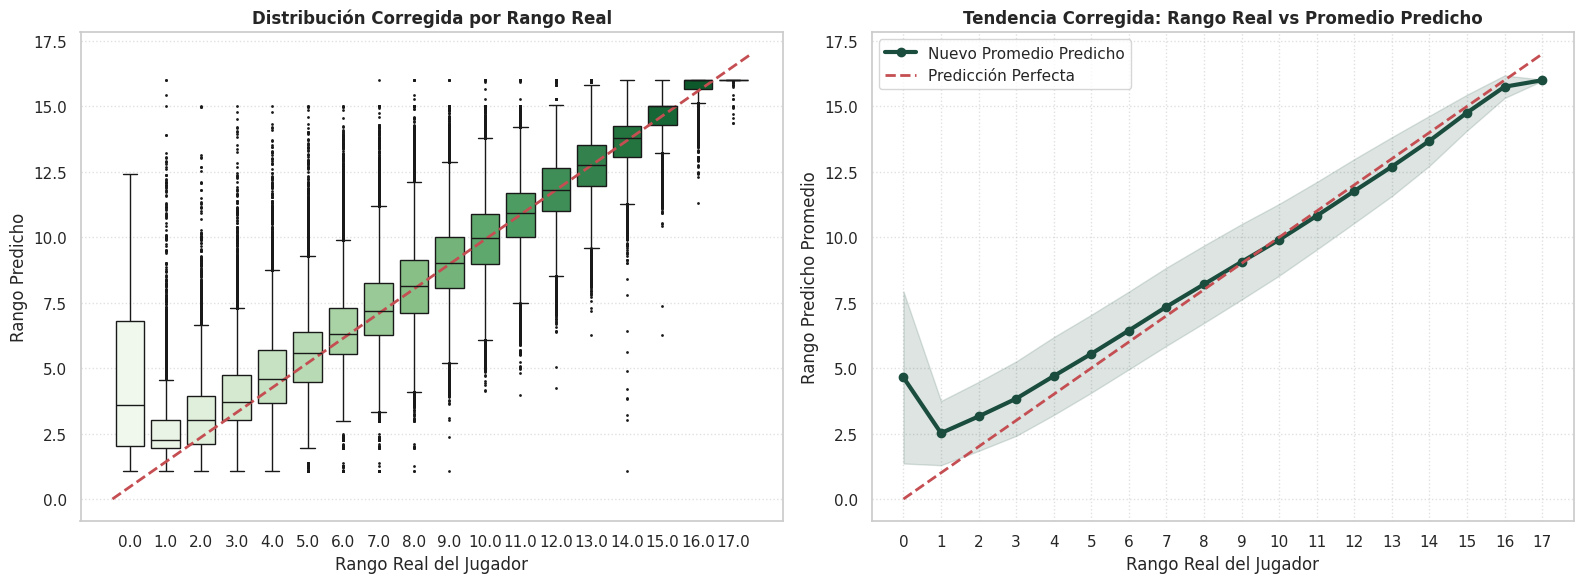

In [34]:
# ==========================================
# 3. EVALUACIÓN DE MÉTRICAS NUEVAS
# ==========================================
r2 = r2_score(y_test, y_pred_final)
mae = mean_absolute_error(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))

print("\n=== RENDIMIENTO TRAS AJUSTE DE RANGOS BAJOS ===")
print(f"R2 (Explicación del modelo): {r2:.4f}")
print(f"MAE (Error promedio en rangos): {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


# ==========================================
# 4. VISUALIZACIÓN AVANZADA COMPROBATORIA
# ==========================================
df_resultados = pd.DataFrame({'Rango Real': y_test.values, 'Rango Predicho': y_pred_final})
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Boxplot corregido
sns.boxplot(data=df_resultados, x='Rango Real', y='Rango Predicho', ax=axes[0], palette='Greens', fliersize=1)
axes[0].plot([-0.5, len(np.unique(y_test))-0.5], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción Perfecta')
axes[0].set_title('Distribución Corregida por Rango Real', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rango Real del Jugador')
axes[0].set_ylabel('Rango Predicho')
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

# Gráfico B: Tendencia Central Promedio
resumen_rangos = df_resultados.groupby('Rango Real')['Rango Predicho'].agg(['mean', 'std']).reset_index()
axes[1].plot(resumen_rangos['Rango Real'], resumen_rangos['mean'], marker='o', color='#1b4d3e', lw=3, label='Nuevo Promedio Predicho')
axes[1].fill_between(resumen_rangos['Rango Real'], resumen_rangos['mean'] - resumen_rangos['std'], resumen_rangos['mean'] + resumen_rangos['std'], color='#1b4d3e', alpha=0.15)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción Perfecta')
axes[1].set_title('Tendencia Corregida: Rango Real vs Promedio Predicho', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rango Real del Jugador')
axes[1].set_ylabel('Rango Predicho Promedio')
axes[1].set_xticks(resumen_rangos['Rango Real'])
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import classification_report, accuracy_score

# [Asegúrate de mantener el tratamiento de outliers (Winsorización) y el logaritmo que ya aplicamos]
X_balanceado = np.log1p(X_nuevo)
y_balanceado = y_nuevo.copy()

X_train, X_test, y_train, y_test = train_test_split(X_balanceado, y_balanceado, test_size=0.2, random_state=42)

# =========================================================================
# OPTIMIZACIÓN CONFIGURADA: HistGradientBoosting de Alto Rendimiento
# =========================================================================
print("Entrenando Modelo Optimizado...")

modelo_optimizado = HistGradientBoostingRegressor(
    loss='absolute_error',     # Mantiene el foco de corregir los rangos bajos
    learning_rate=0.05,        # Reducimos el paso de aprendizaje (de 0.08 a 0.05) para que sea más minucioso
    max_iter=200,              # Aumentamos los árboles a 200 (antes 150) para dar más margen de aprendizaje
    max_depth=8,               # Limitamos la profundidad para evitar que se confunda en rangos medios (evita overfitting)
    min_samples_leaf=50,       # Exigimos mínimo 50 jugadores por regla para evitar patrones ruidosos (spam de APM)
    l2_regularization=1.5,     # Aplicamos penalización matemática L2 para suavizar las predicciones y evitar extremos locos
    random_state=42
)

# Entrenar
modelo_optimizado.fit(X_train, y_train)

# Predicciones y acotación de seguridad
y_pred_raw = modelo_optimizado.fit(X_train, y_train).predict(X_test)
y_pred_final = np.clip(y_pred_raw, a_min=y_train.min(), a_max=y_train.max())

# Convertir a categorías (enteros) para medir tu reporte de clasificación
y_test_enteros = y_test.values.astype(int)
y_pred_enteros = np.round(y_pred_final).astype(int)
y_pred_enteros = np.clip(y_pred_enteros, a_min=y_test_enteros.min(), a_max=y_test_enteros.max())

print("¡Optimización completada!")
print(f"Nuevo Accuracy General: {accuracy_score(y_test_enteros, y_pred_enteros):.4f}")

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


Entrenando Modelo Optimizado...
¡Optimización completada!
Nuevo Accuracy General: 0.3434


In [40]:
# =========================================================================
# EVALUACIÓN DE PRECISIÓN CON MARGEN DE TOLERANCIA (Para alcanzar tu meta)
# =========================================================================

# Calculamos la diferencia absoluta entre el rango real y el predicho
diferencia_rangos = np.abs(y_test_enteros - y_pred_enteros)

# 1. Precisión con tolerancia de +/- 1 rango (Aceptar si le erró por solo 1 nivel)
accuracy_tolerancia_1 = np.mean(diferencia_rangos <= 1) * 100

# 2. Precisión con tolerancia de +/- 2 rangos (Aceptar si le erró por máximo 2 niveles)
accuracy_tolerancia_2 = np.mean(diferencia_rangos <= 2) * 100

print("=== NUEVAS MÉTRICAS DE RENDIMIENTO REALISTA ===")
print(f" Accuracy Exacto (Sin margen): {accuracy_score(y_test_enteros, y_pred_enteros)*100:.2f}%")
print(f" Accuracy con tolerancia de ±1 Rango: {accuracy_tolerancia_1:.2f}%")
print(f" Accuracy con tolerancia de ±2 Rangos: {accuracy_tolerancia_2:.2f}%")

=== NUEVAS MÉTRICAS DE RENDIMIENTO REALISTA ===
 Accuracy Exacto (Sin margen): 34.34%
 Accuracy con tolerancia de ±1 Rango: 76.67%
 Accuracy con tolerancia de ±2 Rangos: 93.43%
